In [2]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import matplotlib.gridspec as gs
import matplotlib as mpl
#import mpl_toolkits.mplot3d.art3d.Line3DCollection
import sys
from wave_approx import *
from wa_phase_diagram import *
mpl.rcParams.update({'font.family': 'CMU Sans Serif', 'axes.unicode_minus' : False})
mpl.rcParams.update({'mathtext.fontset': 'cm', 'mathtext.default':'it'})
%load_ext autoreload
%autoreload 2
"""
basic approx.:
    Poisson approximation of Triplet rule + rate homeostasis
    Wilson-Cowan V1
exact0: basic approx.
approx3: basic approx + update W only between sweeps (fixed within sweep)
approx2: approx3 + firing rate follows input instantaneously
approx1: approx2 + ignore W-r interaction within the sweep
""";

In [3]:
quad = False
fork_ivp = True
square = False 

n = 5
p = np.linspace(0.05,0.95,n)
#p[3] = 0.48
#p[5] = 0.502
#p[6] = 0.52
l = 8
rLTD = 0.3
r0 = 6
rx = 20
tau = 1
d = 4
v = 3.2
A = 0.002
k = 0.114*0.017*A
print(k)
tau_m = 0.02
gL = 40
w0 = 0.1
cap = 32
dt = 1e-3

y0 = np.array([0, 0])
y1 = np.array([0, 0])
y2 = np.array([0, 0])
y3 = np.array([0, 0, 0])

L = 2*l*np.sqrt(2) + 2*d
T = L/v
print(f'T = {T:.3f}s')
# first T
nt = int(T/dt)+2
t = np.arange(nt)*dt
print(f'dt = {dt:.3e}, t[-1] = {t[-1]}')
nx = 101
x = np.linspace(0,2*l, nx)
w_init = w0*np.ones(nx)

if not square:
    half_form = half_circle_height
    iint_form = iint_circle_chord
    int_form = int_circle_chord
    if quad:
        form = half_circle_height
    else:
        form = iint_circle_chord
else:
    half_form = half_square 
    iint_form = iint_square
    int_form = int_square
    if quad:
        form = half_square
    else:
        form = iint_square
 

3.876000000000001e-06
T = 9.571s
dt = 1.000e-03, t[-1] = 9.572000000000001


no fp
f(0) = -22272.53586200482, f(2/3*r0):= f(13.333333333333332)= -23457.721047190007
Stable single fp = [36.61402218775528, 1.0913936421275139e-11]
f(0) = -3.593123297529809e-12, f(2/3*r0):= f(13.333333333333332)= -1185.1851851851889
Stable single fp = [20.000000000000007, 4.485550956190385e-14]
no fp
no fp
k = 3.876e-06, coef_0 = 1.550e-03, coef_1 = 12.8


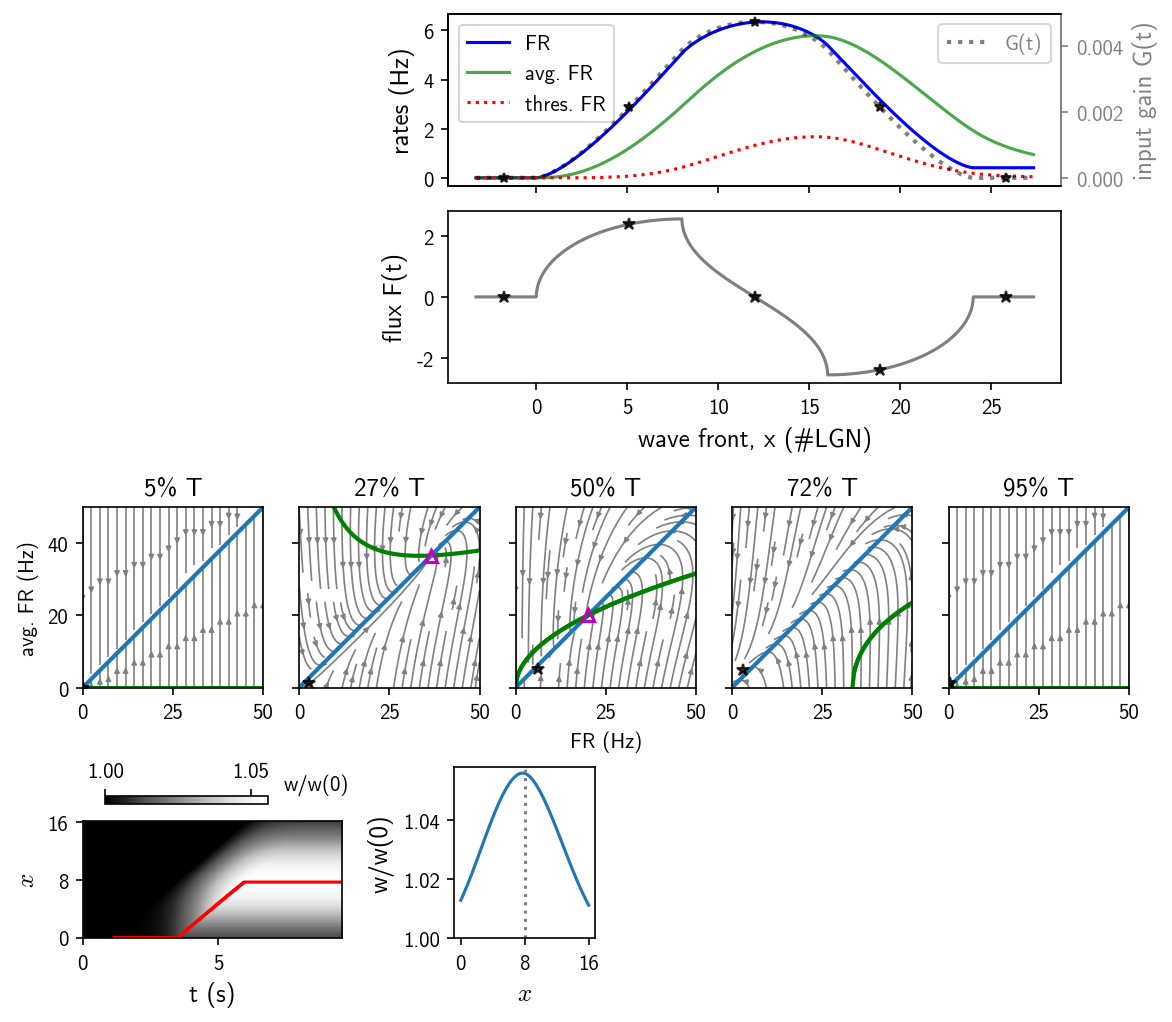

In [3]:
r_max = 50
r = np.linspace(0, r_max, 30)
rbar = np.linspace(0, r_max, 30)
# solve approx2, plot trace
fig = plt.figure(figsize = (9,8), dpi = 150)
hr = [7,7,8,7]
grid = gs.GridSpec(ncols = 5, nrows = 4, figure = fig, height_ratios = hr, hspace = 0.4)

sol2 = solve_ivp(get_approx2(w0, True, half_form, iint_form, k = k, l = l, d = d, v = v, r0 = r0/rLTD, rx = rx, gL = gL, tau = tau), t, y2)

# phase plane
F = k*rx*rx*int_form(T*p, v=v, d=d, l=l)/gL
mks = {'Stable': '^m', 'Unstable': '*m', 'Saddle':'om', 'Degenerated': 'dm', 'Non-isolated':'sm'}
label_fs = 'medium'
label_FS = 'large'
for i in range(n):
    ax = fig.add_subplot(grid[2, i])
    phase_plane(get_dF2(w0, True, half_form, iint_form, T*p[i], k = k, r0 = r0/rLTD, l = l, d = d, v = v, rx = rx, tau = tau, gL = gL), r, rbar, ax = ax)
    _r = np.linspace(0,r[-1], 100)
    _rbar, ro = nullcline2(_r, w0, True, half_form, iint_form, T*p[i], k, l, d, v, r0/rLTD, rx, gL)
    ax.plot(_r, _rbar, 'g', lw = 2, alpha = 1, zorder = 0)
    _x_bot, _x_top = get_xrange(T*p[i],v,d,l)
    _G_sign = half_form(_x_top, l) - half_form(_x_bot, l)
    if _G_sign <= 1e-14:
        if np.isnan(ro):
            ro = 0
        iro = np.nonzero(ro - _r <= 0)[0][0]
        __r = np.insert(_r, max([0,iro]), ro)
        _rbar[iro:][np.isnan(_rbar[iro:])] = 0
        __rbar = np.insert(_rbar, max([0,iro]), 0)
        ax.plot(__r, __rbar, 'g', lw = 2, alpha = 1)
        #ax.plot(ro, 0, 'og', ms = 8, fillstyle = 'none', mew = 2, lw = 2, alpha = 1, zorder = 0)
    ax.plot(_r, _r, lw = 2, alpha = 1, zorder = 0)
    x_bot, x_top = get_xrange(T*p[i],v,d,l)
    Gt = 2*v*rx*w0*(half_form(x_top, l) - half_form(x_bot, l))/gL
    roots, types = solve_for_fp(r0/rLTD, F[i], Gt)
    if roots is not None:
        for root, typ in zip(roots, types):
            ax.plot(root, root, mks[typ], mfc = 'none', mew = 1.5)
        #ax.set_title(f'{p[i]*100:.0f}% T \n F(t) = {F[i]:.2e}\n G(t)={Gt:.1f}', fontsize = 'xx-small')
        ax.set_title(f'{p[i]*100:.0f}% T', fontsize = label_FS)
    else:
        #ax.set_title(f'{p[i]*100:.0f}% T \n F(t) = {F[i]:.2e}\n G(t)={Gt:.1f}, {types}', fontsize = 'xx-small')
        #ax.set_title(f'{p[i]*100:.0f}% T\n{types}', fontsize = 'xx-small')
        ax.set_title(f'{p[i]*100:.0f}% T', fontsize = label_FS)
    if i > 0:
        ax.set_yticklabels([])
    it = np.nonzero(T*p[i] - sol2.t <= 0)[0][0]
    ax.plot(sol2.y[0,it], sol2.y[1,it], '*k', ms = 6, alpha = 0.8)
    ax.set_xlim(r[0], r[-1])
    ax.tick_params(axis = 'both', labelsize = label_fs)
    ax.set_ylim(rbar[0], rbar[-1])
    ax.set_aspect('equal')
    if i == 0:
        ax.set_ylabel('avg. FR (Hz)')
    if i == n//2:
        ax.set_xlabel('FR (Hz)')

ax = fig.add_subplot(grid[0, 2:])
xt = sol2.t*v-2*l*(np.sqrt(2)-1)/2
ax.plot(xt, sol2.y[0,:], 'b', label = 'FR')
ax.plot(xt, sol2.y[1,:], 'g', label = 'avg. FR', alpha = 0.7)
print(f'k = {k:.3e}, coef_0 = {k*rx*rx:.3e}, coef_1 = {2*v*rx*w0}')
ax.plot(xt, np.power(sol2.y[1,:],2)/r0*rLTD, ':r', label = 'thres. FR')

ax.set_ylabel('rates (Hz)', fontsize = label_FS)
ax.legend(loc = 'upper left')
#ax.set_xlabel('wave front (#LGN = vt, v = 3.2 LGN/s)', fontsize = label_FS)
ax.set_xticklabels([])
ax.spines['right'].set_color('gray')
ax2 = ax.twinx()
ax2.plot(T*p*v-2*l*(np.sqrt(2)-1)/2, F, '*k', ms = 5, alpha = 0.8)
ax2.plot(t*v-2*l*(np.sqrt(2)-1)/2, k*rx*rx*int_form(t, v=v, d=d, l=l)/gL, ':k', lw = 2, alpha = 0.5, label = 'G(t)')
ax2.legend(labelcolor = 'gray')
ax2.set_ylabel('input gain G(t)', fontsize = label_FS, color = 'gray')
ax2.tick_params(axis = 'y', colors = 'gray')
ax2.spines['right'].set_color('gray')
chartBox = ax.get_position()
ax.set_position([chartBox.x0 - 0.05, chartBox.y0, chartBox.width*1, chartBox.height])
#ax.set_position([chartBox.x0, chartBox.y0, chartBox.width*0.9, chartBox.height])

ax = fig.add_subplot(grid[1, 2:])
x_bot, x_top = get_xrange(t,v,d,l)
ax.plot(t*v-2*l*(np.sqrt(2)-1)/2, 2*v*rx*w0*(half_form(x_top, l) - half_form(x_bot, l))/gL, color = 'k', alpha = 0.5)
_x_bot, _x_top = get_xrange(T*p,v,d,l)
ax.plot(T*p*v-2*l*(np.sqrt(2)-1)/2, 2*v*rx*w0*(half_form(_x_top, l) - half_form(_x_bot, l))/gL, '*k', ms = 6, alpha = 0.8)
ax.set_ylabel('flux F(t)', fontsize = label_FS)
#ax.set_xlabel('wave front (#LGN)', fontsize = label_FS)
ax.set_xlabel('wave front, x (#LGN)', fontsize = label_FS)
chartBox = ax.get_position()
ax.set_position([chartBox.x0 - 0.05, chartBox.y0+0.038, chartBox.width*1, chartBox.height])
#ax.set_position([chartBox.x0, chartBox.y0+0.038, chartBox.width*0.9, chartBox.height])

ax0 = fig.add_subplot(grid[3, 0])
ax1 = fig.add_subplot(grid[3, 1])
# plot W over time
w2 = next_W(t,w_init,sol2.y[0,:],sol2.y[1,:], k,l,d,v,rx,r0/rLTD, end_only = False)
w2[w2>w0*cap] = w0*cap
show_w_over_t(w2/w0, dt, 't (s)', 'w/w(0)', l, ax = [ax0, ax1], fs = label_FS)

fig.savefig('single_wave.png')
fig.savefig('single_wave.svg')

In [4]:
### iter_sweep('exact2', nT = 1, w0 = w0, l = l, d = d, v = v, k = k/A, A = A, rLTD = rLTD, r0 = r0, rx = rx, tau = tau, tau_m = tau_m, gL = gL, cap = cap, nx = nx, nt = nt, plot = True, theme = 'check', fork_ivp = fork_ivp, shape = 'circle', reverse = 1, norm_w = 0, figsize = (10, 6));

brentq brackets: f(0) = 477.9493837949346, f(2/3*r0) = -707.2358013902506, f(r0) = 477.9493837949346
double fp = [5.801993999581733, 5.684341886080802e-14]; [18.621701868852302, -2.8421709430404007e-13]
tau = -0.9056140758369099


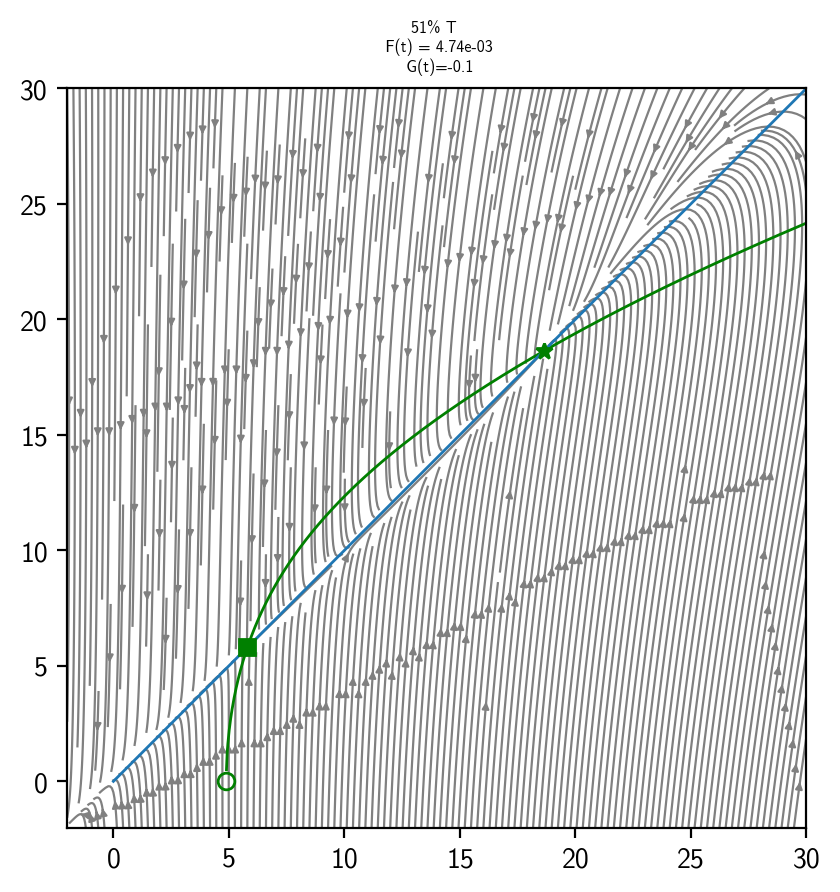

In [5]:
r_max =30 
r = np.linspace(-2, r_max, 20)
rbar = np.linspace(-2, r_max, 20)
perc = 0.51
F = k*rx*rx*int_form(T*perc, v=v, d=d, l=l)/gL
fig, ax = plt.subplots(dpi = 200)
phase_plane(get_dF2(w0, True, half_form, iint_form, T*perc, k = k, r0 = r0/rLTD, l = l, d = d, v = v, rx = rx, tau = tau, gL = gL), r, rbar, ax = ax, d = 4)
_r = np.linspace(0,r[-1], 1000)
_rbar, ro = nullcline2(_r, w0, True, half_form, iint_form, T*perc, k, l, d, v, r0/rLTD, rx, gL)
ax.plot(_r, _rbar, 'g', lw = 1, alpha = 1, zorder = 0)

if ro is not None:
    ax.plot(ro, 0, 'og', fillstyle = 'none', alpha = 1, zorder = 0)
ax.plot(_r, _r, lw = 1, alpha = 1, zorder = 0)
x_bot, x_top = get_xrange(T*perc,v,d,l)
Gt = 2*v*rx*w0*(half_form(x_top, l) - half_form(x_bot, l))/gL
roots, types = solve_for_fp(r0/rLTD, F, Gt)
mks = {'Stable': '*g', 'Unstable': '*r', 'Saddle':'gs', 'Non-isolated': 'g^'}
if roots is not None:
    for root, typ in zip(roots, types):
        ax.plot(root, root, mks[typ])
    ax.set_title(f'{perc*100:.0f}% T \n F(t) = {F:.2e}\n G(t)={Gt:.1f}', fontsize = 'xx-small')
else:
    ax.set_title(f'{perc*100:.0f}% T \n F(t) = {F:.2e}\n G(t)={Gt:.1f}, {types}', fontsize = 'xx-small')
ax.set_xlim(-2,r_max)
ax.set_ylim(-2,r_max)
ax.set_aspect('equal')

In [6]:
def get_Gtau(which, f, r0_rLTD):
    if r0_rLTD*f >= 1:
        if which == 1:
            tau_r = r0_rLTD + np.sqrt(f*f*r0_rLTD*r0_rLTD - f*r0_rLTD)/f
        else:
            tau_r = r0_rLTD - np.sqrt(f*f*r0_rLTD*r0_rLTD - f*r0_rLTD)/f
        if tau_r*f*(3*tau_r/r0_rLTD-2) <= 0:
            return np.nan
        else:
            return np.power(tau_r,2)*(tau_r - r0_rLTD)/r0_rLTD*f
    else:
        return np.nan

def stability_diagram(Gt, Ft, r0, rLTD, tsample = True, fs = 8):
    nt = Ft.size
    x_fpt = 1.07
    fig, ax = plt.subplots(dpi = 120, figsize = (3,3))
    
    points = np.array([Gt, Ft]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    norm = plt.Normalize(0,100)
    lc = LineCollection(segments, cmap='viridis', norm=norm, joinstyle='round', capstyle = 'round')
    # Set the values used for colormapping
    lc.set_array(np.linspace(0,100,nt+1)[:-1])
    lc.set_linewidth(3)
    lc.set_alpha(0.5)
    trace = ax.add_collection(lc)
    fig.colorbar(trace, ax=ax, label = 'time (%)', shrink = 0.5, anchor = (0,0))   
    if tsample:
        j = 0
        for t in tsample:
            it = int(t*(nt-1))
            if j == 0:
                ax.plot(Gt[it], Ft[it], 'sr', ms = 2.0, alpha = 1.0, label = 'trace sample')
            else:   
                ax.plot(Gt[it], Ft[it], 'sr', ms = 2.0, alpha = 1.0)
            j += 1
    ymax = Ft.max()*1.2
    r0_rLTD = r0/rLTD
    G = np.linspace(0,Gt.max()*1.2,200*int(r0_rLTD))
    line0 = ax.plot(G, np.zeros_like(G), '--', lw = 1, label = 'non-isolated,\n$r^{\\ast}=0$', color = 'gray')
    line1 = ax.plot(G, -4/27*r0_rLTD*r0_rLTD*G, ':', lw = 1, label = 'degenerate,\n$r^{\\ast}=2/3r_{0}$', color = 'gray')
    degen_y = lambda f: -4/27*r0_rLTD*r0_rLTD*f
    ax.text(G.max()*x_fpt, ymax*0.06, '1 F.P.', fontsize = fs-1, fontstyle = 'italic', horizontalalignment='right')
    ax.text(G.max()*x_fpt*1.05, degen_y(G.max())/3*2, '2 F.P.\'s', fontsize = fs-1, fontstyle = 'italic', horizontalalignment='right')
    ax.text(G.max()*x_fpt, degen_y(G.max())*1.3, '0 F.P.', fontsize = fs-1, fontstyle = 'italic', horizontalalignment='right')

    G_tau0 = np.array([get_Gtau(0, g, r0_rLTD) for g in G])
    G_tau1 = np.array([get_Gtau(1, g, r0_rLTD) for g in G])
    if not np.isnan(G_tau1).all():
        G1 = G[np.logical_not(np.isnan(G_tau1))].min()
        ax.text(G1 + G.max()*0.08, ymax*0.2, 'Unstable', fontsize = fs, horizontalalignment='left')
        ax.text(G1 - G.max()*0.08, ymax*0.2, 'Stable', fontsize = fs, horizontalalignment='right')
        line4 = ax.plot(G, G_tau1,  '-.k', lw = 1)
    else:
        ax.text(G.max()*0.3, ymax*0.3, 'Stable', fontsize = fs+3, horizontalalignment='left')
    if not np.isnan(G_tau0).all():
        G0 = G[np.logical_not(np.isnan(G_tau0))].min() * 1.6
        ax.text(G0, degen_y(G0*0.6)/3*2.5, '+Saddle', fontsize = fs, horizontalalignment='center', verticalalignment = 'center', alpha = 1.0, color = 'gray')
        line3 = ax.plot(G, G_tau0,  '-.k', lw = 1)
    else:
        ax.text(G.max()*0.45, degen_y(G.max()*0.5)/3*2, '+Saddle', fontsize = fs+0.5, horizontalalignment='left', alpha = 1.0, color = 'gray')
    
    ymin = degen_y(G.max())*1.5
    ax.set_ylim(top=ymax/1.2*1.05, bottom = ymin)
    #ax.plot([0,0], [ymin, ymax], '-k', lw = 1, alpha = 0.5, label = 'Line attr.,\n$r^\\ast=0$')
    #ax.plot([0,0], [ymin, ymax], '-k', lw = 1, alpha = 0.5, label = 'Line attr.')
    ax.set_xlim(left=-Gt.max()*0.01, right = Gt.max()*1.35)
    ax.set_xlabel(r'input gain $G(t)$', fontsize = fs+2)
    ax.set_ylabel(r'flux $F(t)$', fontsize = fs+2)
    #ax.legend(loc = 'best', bbox_to_anchor=(0.45, 0.85), fontsize = 'xx-small')
    #ax.legend(loc = 'outside upper right', fontsize = fs-1)
    #ax.legend(loc = 'best', fontsize = 10)
    ax.spines[['right', 'top']].set_visible(False)
    ax.legend(loc = 'upper left', bbox_to_anchor=(0.75, 0.9), fontsize = fs-1)
    return fig, ax


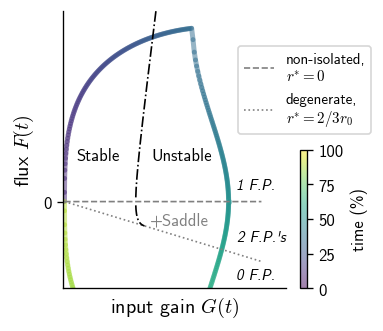

In [7]:
r0 = 6
rLTD = 0.7
gL = 40 
nt = 500
l = 32
d = 14
v = 8
#v = 25.6 # 8 x 3.2
w0 = 0.1
A = 0.5
rx = 8
k = 0.114*0.017*A
#pd = [0.2, 0.4, 0.45, 0.5, 0.55, 0.6, 0.8]
pd = []
L = 2*l*np.sqrt(2) + 2*d
T = L/v
Ft = np.zeros(nt)
Gt = np.zeros(nt)
for i in range(nt):
    Gt[i] = k*w0*rx*rx*int_form(T*i/(nt-1), v=v, d=d, l=l)/gL
    x_bot, x_top = get_xrange(T*i/(nt-1),v,d,l)
    Ft[i] = 2*v*rx*w0*(half_form(x_top, l) - half_form(x_bot, l))/gL
p = np.linspace(0.05,0.95,n)
fig, ax = stability_diagram(Gt, Ft, r0, rLTD, fs = 10, tsample = pd)
ax.set_xticks([])
ax.set_yticks([0])
ax.set_ylim([Ft.min() * 0.5, Ft.max() * 1.1])
#ax.tick_params(axis = 'both')
fig.savefig(f'F-G_phase_diagram-l{l}-d{d}_match.png')
fig.savefig(f'F-G_phase_diagram-l{l}-d{d}_match.svg')

T = 23.713, dt = 7.813e-03, each LGN activated for 10.5%
max weight possible: 3.200e+00
using method exact2
r0 * G <= 0.07433297672116487 < 1, the larger fixed point of the linearized system is always stable
100/100...plot weight at sweep 99
plot sample sweep #99
 ymax = 109.13274077034457
max fixed point in coil: (42.23886060659997, 48.10647746928357)


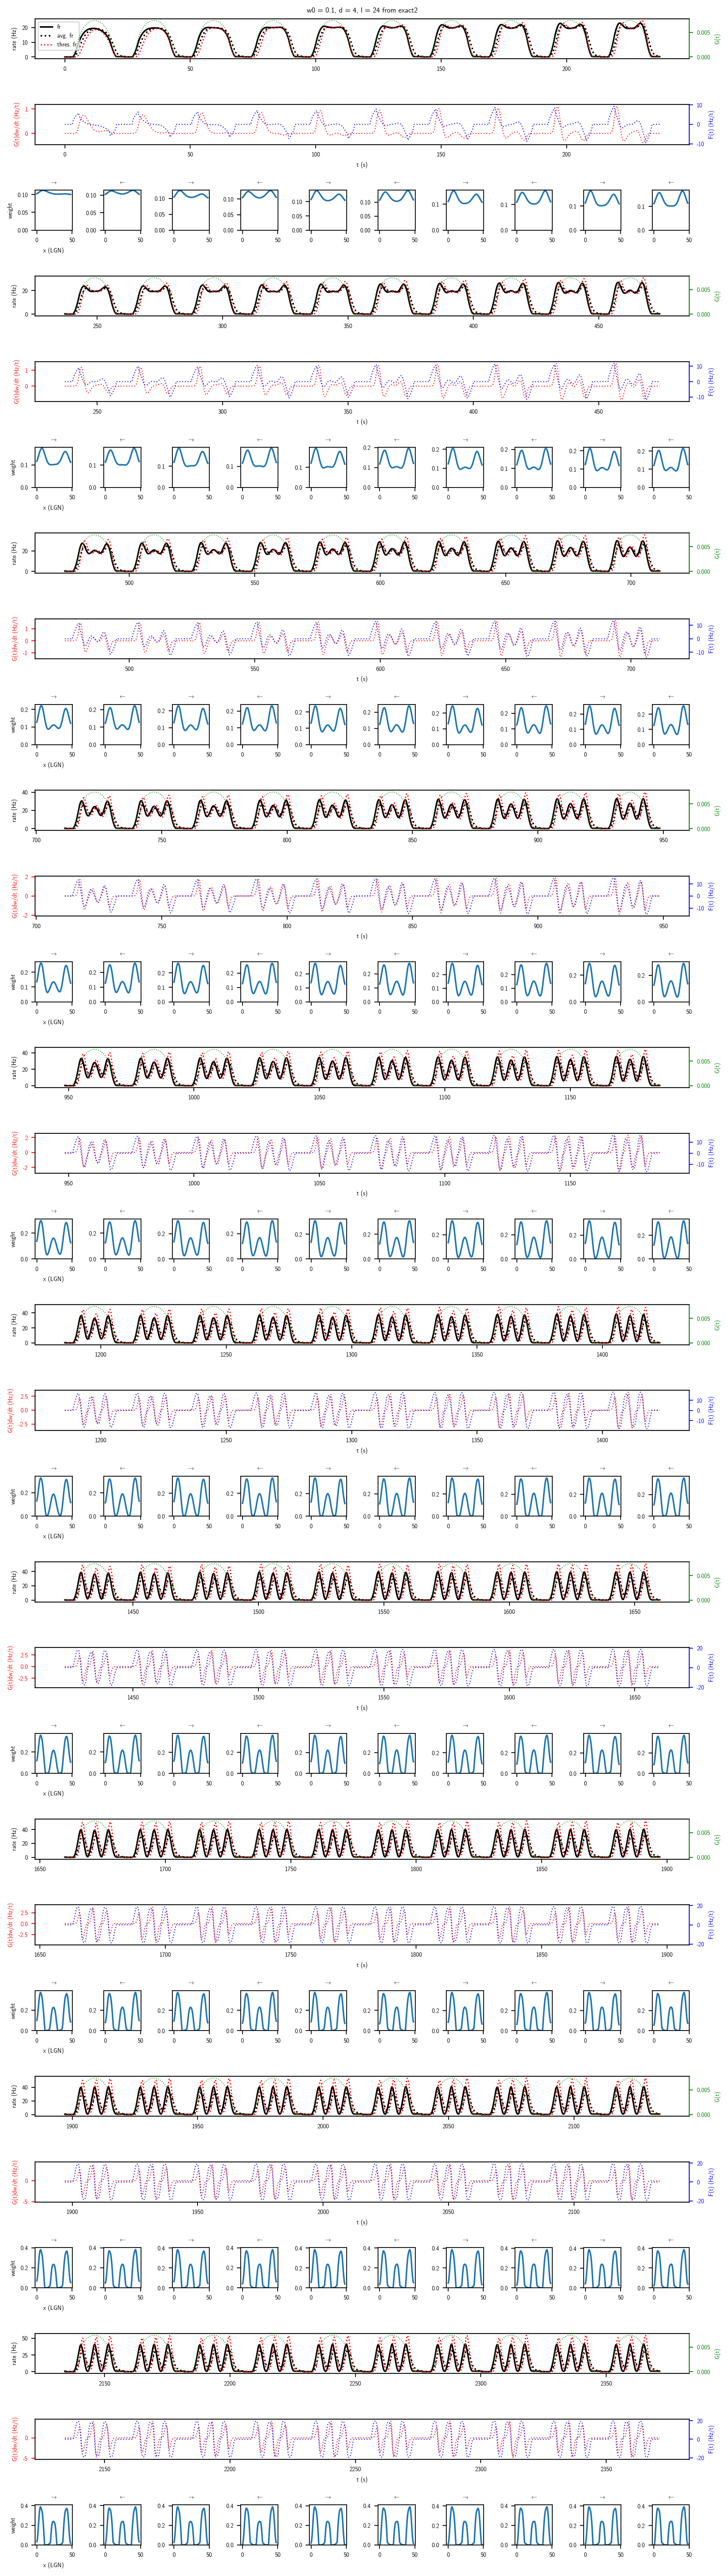

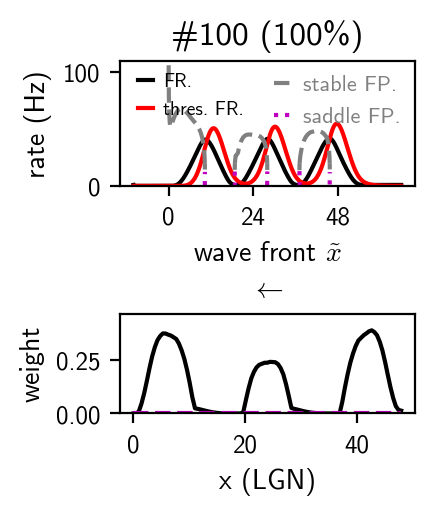

In [8]:
l = 24
d = 4
v = 3.2
r0 = 6
rLTD = 0.3
rx = 20
gL = 40
w0 = 0.1
A = 0.01
k = 0.114*0.017
nT = 100
tau = 1
F_perc = 1.0
figsize = None
nx = 101
#figsize = (10,6)
dt = 1/128
L = l*2*np.sqrt(2) + 2*d
T = L/v
nt = int(T/dt)
wt, r, rbar, dt, Gt, G0, Ft = iter_sweep('exact2', nT = nT, w0 = w0, l = l, d = d, v = v, k = k, A = A*w0, rLTD = rLTD, r0 = r0, rx = rx, tau = tau, tau_m = tau_m, gL = gL, cap = cap, nx = nx, nt = nt, plot = True, theme = 'check', fork_ivp = fork_ivp, shape = 'circle', reverse = 1, norm_w = 0, figsize = figsize, F_perc = F_perc, return_FG = True, diagram_perc = [1.0], pdiagram_idx=0, pd = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8], less = 1)

 ymax = 81.84955557775842
max fixed point in coil: (42.23886060659997, 48.10647746928357)


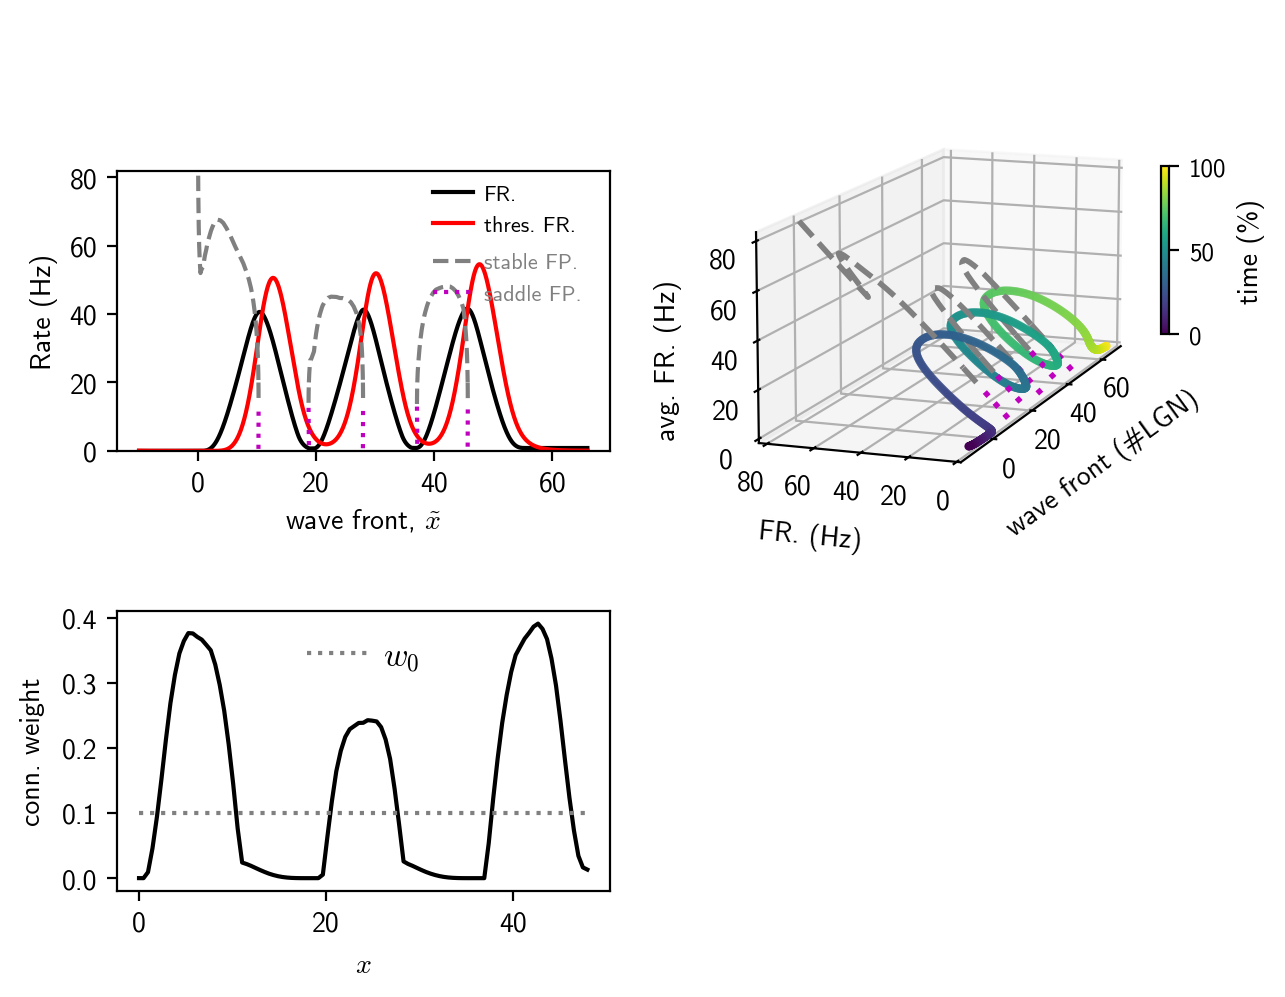

In [9]:
import pickle
fig = plt.figure(dpi = 200, figsize = (10,10)) 
ax1 = fig.add_subplot(221)
ax2 = fig.add_subplot(222, projection = '3d')
t = dt + np.arange(nt)*dt
dwdt = (r*(r-rbar*rbar/r0))
pscale = 1.5
#ax2 = None
xf = lambda x:x*v-(np.sqrt(2)-1)*l
fp = temporal_trace(r0/rLTD, G0[-nt:], Ft[-nt:], r[-nt:], rbar[-nt:], t, wt[:,-nt:], False, half_form, iint_form, rx, v, l, k*A*w0, d, gL, fs = 10, ax = ax1, ax2 = ax2, xf = xf, pscale = pscale, plot_ylabel = True, plot_xlabel = True, pLeg = True, less = 1)
box = ax1.get_position()
ax1.set_position([box.x0 + 0.15, box.y0+0.1, box.width*0.7, box.height*0.4])
ax1.set_xlabel(r'wave front, $\tilde{x}$')
ax3 = fig.add_subplot(223)
ax3.plot(np.linspace(0,2*l,nx), wt[:,-1], 'k')
ax3.set_ylabel('conn. weight', fontsize = 10, labelpad = 6)
ax3.set_xlabel(r'$x$', fontsize = 10, labelpad = 6)
ax3.plot([0,2*l], [w0, w0], ':', color = 'grey', label = r'$w_0$')
ax3.legend(frameon = False, handletextpad = 0.5, handlelength = 1.8, fontsize = 12)
box = ax3.get_position()
ax3.set_position([box.x0 + 0.15, box.y0+0.3, box.width*0.7, box.height*0.4])
fig.savefig('3d_trace_phase_diagram.png')
fig.savefig('3d_trace_phase_diagram.svg')

In [11]:
print('saddle:')
[print(f'({xf(min(h[0])):.4f}, {xf(max(h[0])):.4f}), ({min(h[1]):.1f}, {max(h[1]):.1f}), {len(h[0])}') for h in fp['Saddle']]
if 'Unstable' in fp:
    print('unstable:')
    [print(f'({xf(min(h[0])):.4f}, {xf(max(h[0])):.4f}), ({min(h[1]):.1f}, {max(h[1]):.1f}), {len(h[0])}') for h in fp['Unstable']]
print('stable:')
[print(f'({xf(min(h[0])):.4f}, {xf(max(h[0])):.4f}), ({min(h[1]):.1f}, {max(h[1]):.1f}), {len(h[0])}') for h in fp['Stable']]

saddle:
(10.2894, 10.3098), (0.6, 12.3), 41
(18.7667, 18.8218), (0.6, 12.6), 61
(27.9640, 27.9880), (0.8, 12.7), 48
(37.1113, 37.1639), (0.6, 12.9), 8
(45.6877, 45.7076), (1.2, 12.1), 40
stable:
(0.0001, 10.2889), (20.1, 639.0), 437
(10.2894, 10.3098), (14.3, 20.0), 41
(18.7667, 18.8218), (14.1, 20.0), 61
(18.8223, 27.9635), (20.0, 45.1), 396
(27.9640, 27.9880), (14.0, 20.0), 48
(37.1113, 37.1639), (13.7, 20.0), 8
(37.1644, 45.6871), (20.0, 48.1), 432
(45.6877, 45.7076), (14.5, 19.9), 40


[None, None, None, None, None, None, None, None]

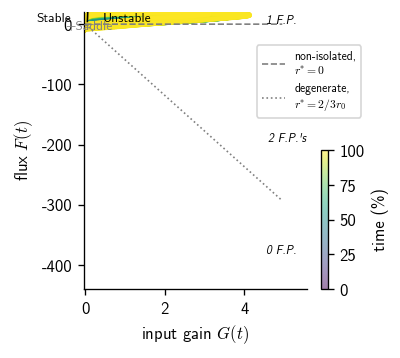

In [12]:
fig, ax = stability_diagram(Gt, Ft, r0, rLTD, tsample = False)
fig.savefig(f'F-G_phase_diagram-l{l}-d{d}.png')
fig.savefig(f'F-G_phase_diagram-l{l}-d{d}.svg')

9.999999999999998
10.000170087221122
10.000072565220714


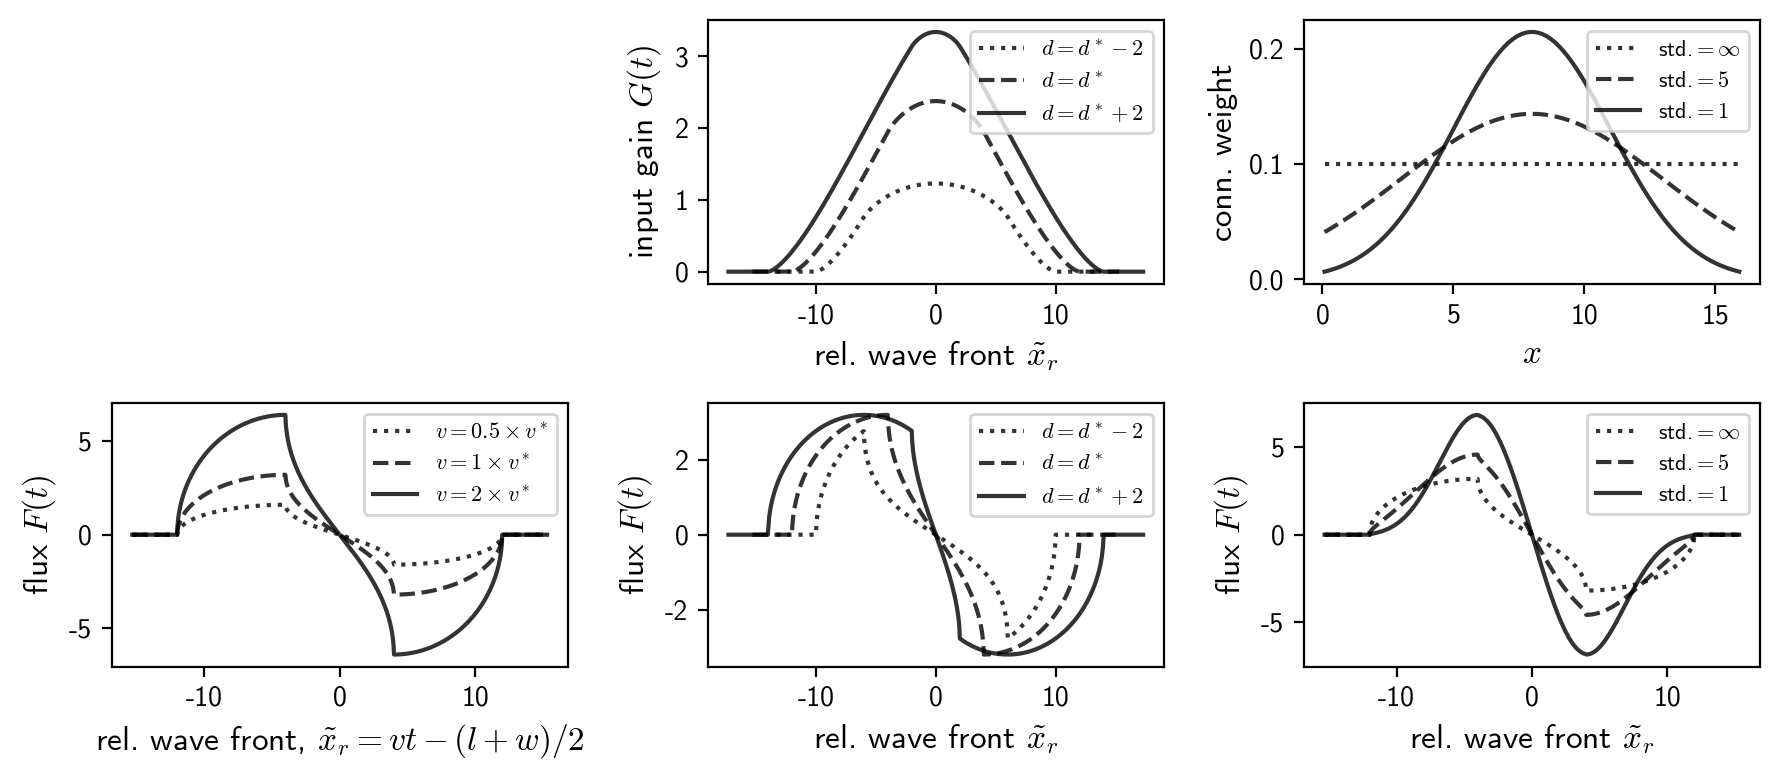

In [13]:
v = 3.2 * 20/16
w0 = 0.1
d = 4
l = 8
L = 2*l*np.sqrt(2) + 2*d
#l0 = l*(np.sqrt(2)-1)
nt = 1001
fig = plt.figure(figsize = (9, 4), dpi = 200)

label_FS = 12
label_fs = 6
ax = fig.add_subplot(234)
###
v0 = 0.5*v
v1 = v
v2 = 2*v
T = L/v0
t0 = np.linspace(0,T,nt)
T = L/v1
t1 = np.linspace(0,T,nt)
T = L/v2
t2 = np.linspace(0,T,nt)
x_bot, x_top = get_xrange(t0,v0,d,l)
ax.plot(t0*v0-L/2, 2*v0*rx*w0*(half_form(x_top, l) - half_form(x_bot, l))/gL, ':k', alpha = 0.8, label = r'$v = 0.5\times v^*$')
x_bot, x_top = get_xrange(t1,v1,d,l)
ax.plot(t1*v1-L/2, 2*v1*rx*w0*(half_form(x_top, l) - half_form(x_bot, l))/gL, '--k', alpha = 0.8, label = r'$v = 1\times v^*$')
x_bot, x_top = get_xrange(t2,v2,d,l)
ax.plot(t2*v2-L/2, 2*v2*rx*w0*(half_form(x_top, l) - half_form(x_bot, l))/gL, '-k', alpha = 0.8, label = r'$v = 2\times v^*$')
#ax.plot(np.array([0, L]) - 2*l*(np.sqrt(2)-1)/2, [0, 0], '-', color = 'gray', lw = 1, alpha = 0.5)
ax.legend(fontsize = label_fs+2)

ax.set_ylabel(r'flux $F(t)$', fontsize = label_FS)
#ax.set_xlabel('wave front (#LGN)', fontsize = label_FS)
ax.set_xlabel(r'rel. wave front, $\tilde{x}_r=vt-(l+w)/2$', fontsize = label_FS)

ax = fig.add_subplot(232)
ax2 = fig.add_subplot(235)
d0 = 2
L = 2*l*np.sqrt(2) + 2*d0
T = L/v
t0 = np.linspace(0,T,nt)
ax.plot(t0*v-L/2, k*rx*rx*int_form(t0, v=v, d=d0, l=l)/gL, ':k', alpha = 0.8, label = r'$d=d^* - 2$')
x_bot, x_top = get_xrange(t0,v,d0,l)
ax2.plot(t0*v-L/2, 2*v*rx*w0*(half_form(x_top, l) - half_form(x_bot, l))/gL, ':k', alpha = 0.8, label = r'$d=d^* - 2$')

d1 = 4
L = 2*l*np.sqrt(2) + 2*d1
T = L/v
t1 = np.linspace(0,T,nt)
ax.plot(t1*v-L/2, k*rx*rx*int_form(t1, v=v, d=d1, l=l)/gL, '--k', alpha = 0.8, label = r'$d = d^*$')
x_bot, x_top = get_xrange(t1,v,d1,l)
ax2.plot(t1*v-L/2, 2*v*rx*w0*(half_form(x_top, l) - half_form(x_bot, l))/gL, '--k', alpha = 0.8, label = r'$d = d^*$')

d2 = 6
L = 2*l*np.sqrt(2) + 2*d2
T = L/v
t2 = np.linspace(0,T,nt)
ax.plot(t2*v-L/2, k*rx*rx*int_form(t2, v=v, d=d2, l=l)/gL, '-k', alpha = 0.8, label = r'$d = d^* + 2$')
x_bot, x_top = get_xrange(t2,v,d2,l)
ax2.plot(t2*v-L/2, 2*v*rx*w0*(half_form(x_top, l) - half_form(x_bot, l))/gL, '-k', alpha = 0.8, label = r'$d = d^* + 2$')

ax.legend(fontsize = label_fs+2)
ax2.legend(fontsize = label_fs+2)
ax.set_ylabel(r'input gain $G(t)$', fontsize = label_FS)
ax2.set_ylabel(r'flux $F(t)$', fontsize = label_FS)
#ax.set_xlabel('wave front (#LGN)', fontsize = label_FS)
ax.set_xlabel(r'rel. wave front $\tilde{x}_r$', fontsize = label_FS)
ax2.set_xlabel(r'rel. wave front $\tilde{x}_r$', fontsize = label_FS)

ax = fig.add_subplot(233)
ax2 = fig.add_subplot(236)
nx = 101
xbin = np.linspace(0,2*l,nx)
L = 2*l*np.sqrt(2) + 2*d
T = L/v
t = np.linspace(0,T,nt)
x_bot, x_top = get_xrange(t,v,d,l)
x = (xbin[1:] + xbin[:-1])/2
w_dist0 = lambda x: w0*np.ones(x.shape)
print(np.sum(w_dist0(x)))
cut_norm_dist = lambda x, sigma: w0*2*l/np.sqrt(2*np.pi)/sigma*np.exp(-0.5*np.power((x-l)/sigma,2))/sp.special.erf(l/np.sqrt(2)/sigma)
ax.plot(x, w_dist0(x), ':k', alpha = 0.8, label = r'std.$ = \infty$')
ax2.plot(t*v-L/2, 2*v*rx*(w_dist0(x_top)*half_form(x_top, l) - w_dist0(x_bot)*half_form(x_bot, l))/gL, ':k', alpha = 0.8, label = r'std.$ = \infty$')
sig = 5
w_dist1 = lambda x: cut_norm_dist(x, sig)
print(np.sum(w_dist1(x)))
ax.plot(x, w_dist1(x), '--k', alpha = 0.8, label = r'std.$ = 5$')
ax2.plot(t*v-L/2, 2*v*rx*(w_dist1(x_top)*half_form(x_top, l) - w_dist1(x_bot)*half_form(x_bot, l))/gL, '--k', alpha = 0.8, label = r'std.$ = 5$')
sig = 3
w_dist2 = lambda x: cut_norm_dist(x, sig)
print(np.sum(w_dist2(x)))
ax.plot(x, w_dist2(x), '-k', alpha = 0.8, label = r'std.$ = 1$')
ax2.plot(t*v-L/2, 2*v*rx*(w_dist2(x_top)*half_form(x_top, l) - w_dist2(x_bot)*half_form(x_bot, l))/gL, '-k', alpha = 0.8, label = r'std.$ = 1$')
ax.legend(fontsize = label_fs+2, loc = 'upper right')
ax2.legend(fontsize = label_fs+2)
ax.set_xlabel(r'$x$', fontsize = label_FS)
ax.set_ylabel('conn. weight', fontsize = label_FS)
ax2.set_xlabel(r'rel. wave front $\tilde{x}_r$', fontsize = label_FS)
ax2.set_ylabel(r'flux $F(t)$', fontsize = label_FS)

fig.tight_layout()
fig.savefig('mechanism_illustrate.png')
fig.savefig('mechanism_illustrate.svg')